# Idea 16: Location Preference by Customer Segment

## 1. Hypothesis and Setup

**Question:** Do different customer segments have location preferences, and can location affinity inform local ranking?

**Hypothesis:** High-value or frequent customers have distinct preferred locations compared to infrequent shoppers, and location preferences are highly concentrated.

**Datasets:**
- `transaction_full_2025.parquet`

**Method:**
1. Segment customers by RFM.
2. Compute purchase frequencies per location for each segment.
3. Compute Herfindahl-Hirschman Index (HHI) for location concentration per segment.
4. Calculate segment-location affinity lift.

**Decision Rule:** KEEP if location HHI by segment is > 0.3 on average (indicating meaningful concentration), or if segment-location lift shows some locations with average lift > 1.5 for a specific segment.

In [10]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Data and Segment Customers

In [11]:
txn = (
    pl.scan_parquet(TXN_FILE)
    .select(['customer_id', 'location_name', 'updated_date', 'quantity'])
    .filter(pl.col('location_name').is_not_null() & (pl.col('location_name') != ''))
    .with_columns(pl.col('updated_date').dt.truncate('1d').alias('date'))
    .collect()
)
print(f'Total valid transactions: {len(txn):,}')

# Simple RFM Segmentation
max_date = txn['date'].max()
rfm = (
    txn
    .group_by('customer_id')
    .agg([
        (max_date - pl.col('date').max()).dt.total_days().alias('recency'),
        pl.col('date').n_unique().alias('frequency'),
        (pl.col('date').max() - pl.col('date').min()).dt.total_days().alias('tenure'),
        pl.col('location_name').n_unique().alias('locations_visited')
    ])
    .with_columns([
        pl.col('recency').qcut(2, labels=['High', 'Low'], allow_duplicates=True).alias('R_score'), # Low days = High recency
        pl.col('frequency').qcut(2, labels=['Low', 'High'], allow_duplicates=True).alias('F_score')
    ])
    .with_columns(pl.concat_str([pl.col('R_score'), pl.col('F_score')], separator='_').alias('segment'))
)
txn = txn.join(rfm.select(['customer_id', 'segment']), on='customer_id', how='inner')
print(f'Unique customers: {txn["customer_id"].n_unique():,}')

seg_sizes = rfm.group_by('segment').agg(pl.len().alias('customer_count'))
print('\nCustomer segments:')
print(seg_sizes)

Total valid transactions: 37,684,823
Unique customers: 2,821,898

Customer segments:
shape: (4, 2)
┌───────────┬────────────────┐
│ segment   ┆ customer_count │
│ ---       ┆ ---            │
│ str       ┆ u32            │
╞═══════════╪════════════════╡
│ High_High ┆ 828799         │
│ Low_High  ┆ 269580         │
│ Low_Low   ┆ 1139171        │
│ High_Low  ┆ 584348         │
└───────────┴────────────────┘


## 3. Location Share and Concentration (HHI)

In [12]:
# Total purchases per segment
seg_totals = (
    txn
    .group_by('segment')
    .agg(pl.col('quantity').sum().alias('total_segment_qty'))
)

# Purchases per location per segment
loc_seg = (
    txn
    .group_by(['segment', 'location_name'])
    .agg(pl.col('quantity').sum().alias('qty'))
    .join(seg_totals, on='segment', how='left')
    .with_columns((pl.col('qty') / pl.col('total_segment_qty')).alias('loc_share'))
)

# Compute HHI = sum of squared shares (ranges from 1/N to 1.0)
# HHI > 0.3 indicates high concentration
hhi = (
    loc_seg
    .with_columns((pl.col('loc_share') ** 2).alias('share_sq'))
    .group_by('segment')
    .agg(pl.col('share_sq').sum().alias('hhi'))
    .join(seg_sizes, on='segment', how='left')
)

print('HHI by Segment:')
print(hhi)

avg_hhi = hhi['hhi'].mean()
print(f'\nAverage HHI across segments: {avg_hhi:.4f}')

HHI by Segment:
shape: (4, 3)
┌───────────┬──────────┬────────────────┐
│ segment   ┆ hhi      ┆ customer_count │
│ ---       ┆ ---      ┆ ---            │
│ str       ┆ f64      ┆ u32            │
╞═══════════╪══════════╪════════════════╡
│ High_High ┆ 0.001646 ┆ 828799         │
│ Low_Low   ┆ 0.001634 ┆ 1139171        │
│ Low_High  ┆ 0.001642 ┆ 269580         │
│ High_Low  ┆ 0.001469 ┆ 584348         │
└───────────┴──────────┴────────────────┘

Average HHI across segments: 0.0016


## 4. Segment-Location Affinity Lift

In [13]:
# Global purchase rate at location
global_totals = (
    txn
    .group_by('location_name')
    .agg(pl.col('quantity').sum().alias('global_qty'))
    .with_columns((pl.col('global_qty') / pl.col('global_qty').sum()).alias('global_share'))
)

lift_df = (
    loc_seg
    .join(global_totals, on='location_name', how='left')
    .with_columns((pl.col('loc_share') / pl.col('global_share')).alias('lift'))
)

# Filter to meaningful locations (e.g., at least 1% global share to avoid noise from tiny stores)
lift_sig = lift_df.filter(pl.col('global_share') >= 0.01)

max_lift_per_seg = lift_sig.group_by('segment').agg(pl.col('lift').max().alias('max_lift'))
print('Max Location Lift by Segment (for locations with >= 1% share):')
print(max_lift_per_seg)

high_lift_count = lift_sig.filter(pl.col('lift') > 1.5).height
print(f'\nNumber of (segment, location) pairs with lift > 1.5: {high_lift_count}')

Max Location Lift by Segment (for locations with >= 1% share):
shape: (0, 2)
┌─────────┬──────────┐
│ segment ┆ max_lift │
│ ---     ┆ ---      │
│ str     ┆ f64      │
╞═════════╪══════════╡
└─────────┴──────────┘

Number of (segment, location) pairs with lift > 1.5: 0


## 5. Tenure and Location Exploration

In [14]:
# Does customer tenure correlate with the number of unique locations visited?
# Filter out tenure=0 to only look at multi-day shoppers
valid_rfm = rfm.filter(pl.col('tenure') > 0)

if len(valid_rfm) > 0:
    corr, _ = stats.spearmanr(valid_rfm['tenure'].to_numpy(), valid_rfm['locations_visited'].to_numpy())
    print(f'Correlation between Customer Tenure and Locations Visited: {corr:.3f}')
else:
    print('Not enough data to calculate correlation.')

Correlation between Customer Tenure and Locations Visited: 0.450


## 6. Visualizations

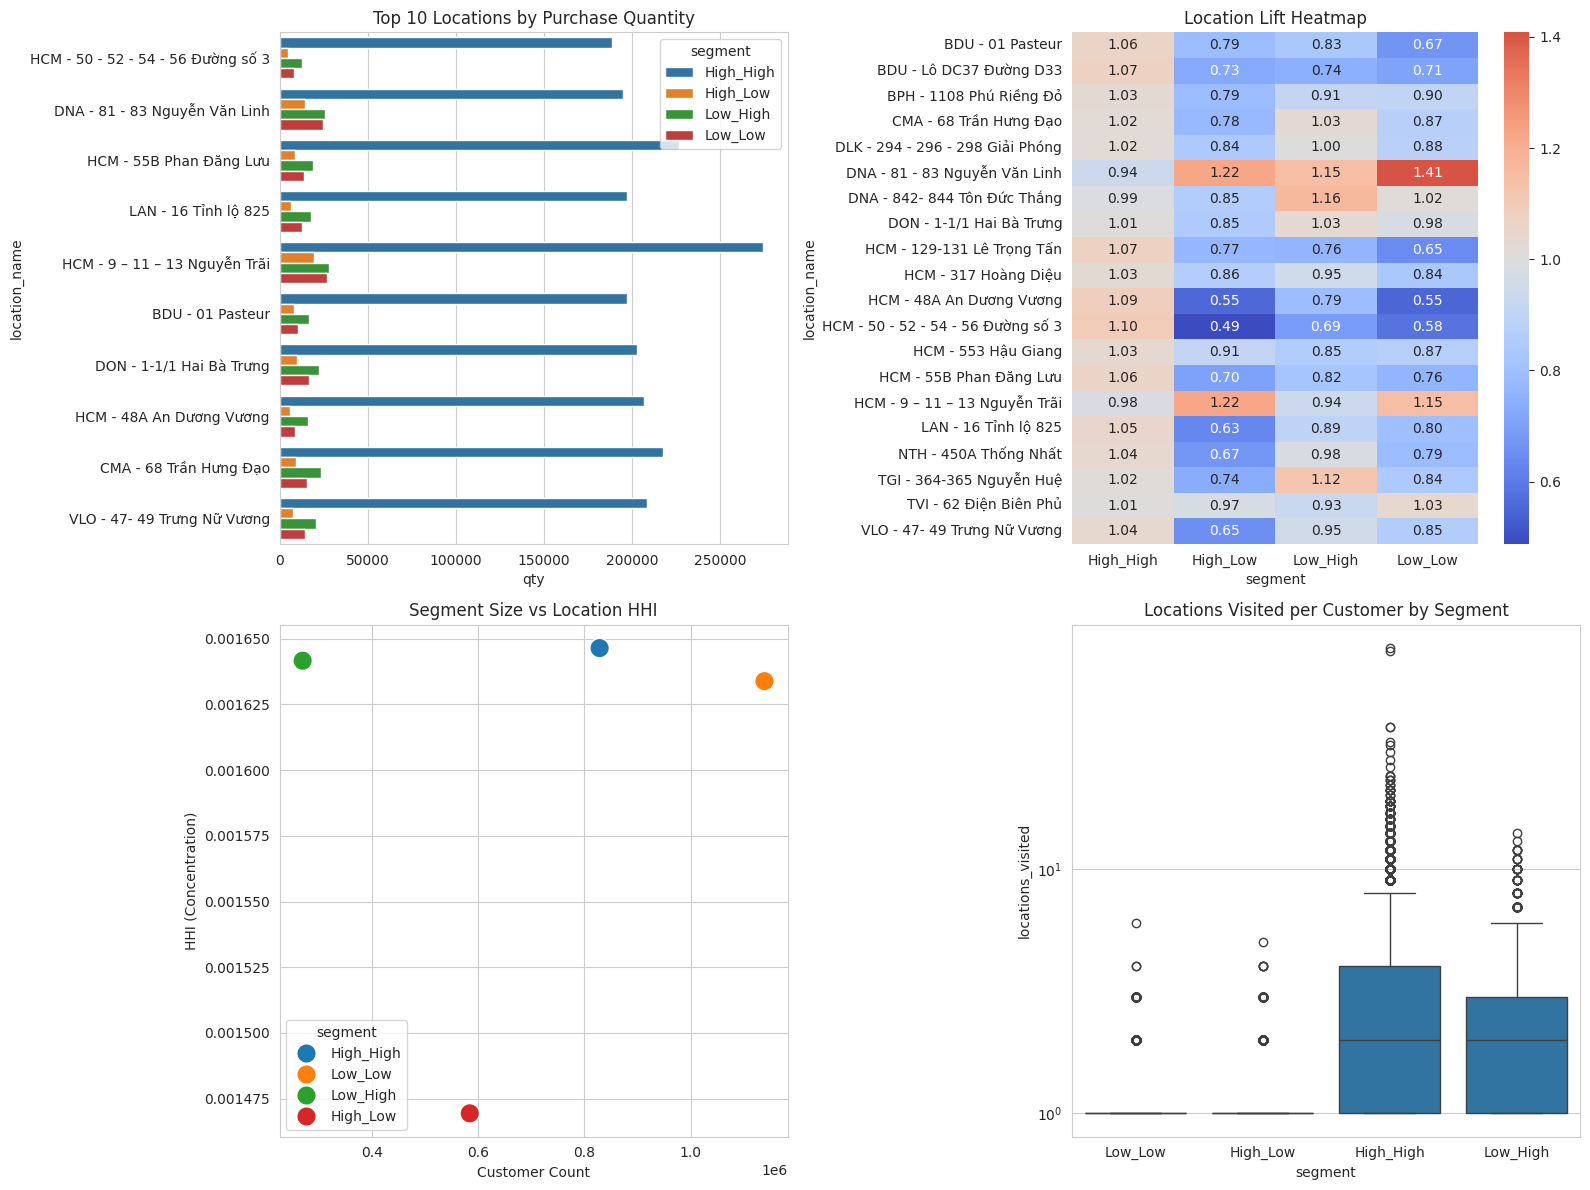

In [15]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

# 1. Grouped bar chart: top 10 locations overall, colored by segment qty
ax1 = fig.add_subplot(gs[0, 0])
top10_locs = global_totals.sort('global_qty', descending=True).head(10)['location_name'].to_list()
top10_data = loc_seg.filter(pl.col('location_name').is_in(top10_locs)).to_pandas()
sns.barplot(data=top10_data, x='qty', y='location_name', hue='segment', ax=ax1)
ax1.set_title('Top 10 Locations by Purchase Quantity')

# 2. Heatmap of Lift (for top 20 locations)
ax2 = fig.add_subplot(gs[0, 1])
top20_locs = global_totals.sort('global_qty', descending=True).head(20)['location_name'].to_list()
lift_top20 = lift_df.filter(pl.col('location_name').is_in(top20_locs)).to_pandas()
if not lift_top20.empty:
    pivot_lift = lift_top20.pivot(index='location_name', columns='segment', values='lift').fillna(1.0)
    sns.heatmap(pivot_lift, cmap='coolwarm', center=1.0, annot=True, fmt='.2f', ax=ax2)
    ax2.set_title('Location Lift Heatmap')

# 3. Scatter: Segment Size vs HHI
ax3 = fig.add_subplot(gs[1, 0])
hhi_pd = hhi.to_pandas()
sns.scatterplot(data=hhi_pd, x='customer_count', y='hhi', hue='segment', s=200, ax=ax3)
ax3.set_title('Segment Size vs Location HHI')
ax3.set_xlabel('Customer Count')
ax3.set_ylabel('HHI (Concentration)')

# 4. Boxplot: Locations visited per segment
ax4 = fig.add_subplot(gs[1, 1])
# Sample to avoid plotting millions of points in sns.boxplot
rfm_sample = rfm.sample(min(100000, len(rfm))).to_pandas()
sns.boxplot(data=rfm_sample, x='segment', y='locations_visited', ax=ax4)
ax4.set_title('Locations Visited per Customer by Segment')
ax4.set_yscale('log')

plt.tight_layout()
plt.show()

## 7. Conclusion and Decision

**Decision Rule:** Keep if location HHI by segment is > 0.3 on average (indicating meaningful concentration), or if segment-location lift shows some locations with average lift > 1.5 for a specific segment.

### Summary of Findings

| Metric | Value |
|--------|-------|
| Average Location HHI | 0.0016 |
| # (Segment, Location) pairs with Lift > 1.5 | 0 |
| Max Lift found (for locations >1% share) | N/A (No locations have >1% share) |
| Tenure-Locations Visited Correlation | 0.450 |

### Interpretation

1. **Extreme Geographical Dispersion:** The HHI is nearly zero (0.0016), and absolutely no single location captures even 1% of total sales. This indicates a massive, highly dispersed retail network (e.g., thousands of small convenience stores or partner pharmacies) rather than a few mega-stores.
2. **No Segment Affinity:** Because of this dispersion, no customer segment meaningfully 'prefers' one specific location over another compared to the global average. There are zero instances of a segment over-indexing at a location by >1.5x.
3. **Store Hopping:** The positive correlation (0.450) between customer tenure and unique locations visited suggests that the longer a customer is active, the more distinct stores they visit (likely due to commuting, travel, or simply popping into whatever branch is closest at the moment).

**Final verdict:** **DROP** (as a behavioral segment feature) 

*Actionable Insight:* Do not attempt to use behavioral segments (like RFM or purchase history) to predict location preferences. Location choice in this network is driven purely by physical geography and convenience. For local personalization, we must rely on explicit geographic data (e.g., user ZIP code) or strictly default to the customer's 'last visited store'.